# Master in Applied Artificial Intelligence

## Course: *Computer Vision for Images and Video*

### **Activity 10.7** - Research on applications of optical flow

---

**Institution:** Tecnológico de Monterrey

**Instructors:** Gilberto Ochoa Ruiz, Daniel Flores Araiza, Ma. del Refugio Meléndez Alfaro

**Authors (Team 38):**

|  FULL NAME                      |     STUDENT ID    |
| :--------------------------:    |:-----------------:|
| Alejandro Díaz Villagómez       |  A01276769        |
| Carlos Rodrigo Sánchez Sierra   |  A01424454        |
| Emiliano Saucedo Arriola        |  A01659258        |

**Date:** November 17th, 2025

---

## 1. Install and Import Dependencies

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from moviepy import VideoFileClip, ImageSequenceClip
from IPython.display import Video

## 2. Load Video and Extract Metadata

In [2]:
video_path = "data/ADAS test video.mp4"

cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration_sec = total_frames / fps

print(f"📌 FPS: {fps}")
print(f"📌 Total frames: {total_frames}")
print(f"📌 Approximate duration: {duration_sec:.2f} seconds")
cap.release()

📌 FPS: 29.97002997002997
📌 Total frames: 554
📌 Approximate duration: 18.49 seconds


## 3. Frame Selection Settings

In [3]:
start_time_sec = 10      # Optional: start later in the video
end_time_sec = duration_sec
step = 2                  # Frame step (higher = faster processing but less precision)

frame_start = int(start_time_sec * fps)
frame_end = int(end_time_sec * fps)

print(f"Processing from frame {frame_start} to {frame_end} with step {step}")

Processing from frame 299 to 554 with step 2


## 4. Compute Optical Flow + Visualization Overlay
Includes:

* HSV flow visualization

* Arrow drawing for direction vectors

* Collision risk detection based on optical flow magnitude

In [4]:
cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_start)

frames_result = []
ret, frame1 = cap.read()
prev_gray = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)

# HSV base (Hue = motion direction, Value = magnitude)
hsv = np.zeros_like(frame1)
hsv[...,1] = 255

collision_alert_frames = []
mag_history = []

COLLISION_THRESHOLD = 3  # Adjust sensitivity: higher = fewer alerts

while cap.isOpened():
    current_pos = cap.get(cv2.CAP_PROP_POS_FRAMES)
    if current_pos > frame_end:
        break

    ret, frame2 = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

    # Farneback Optical Flow calculation
    flow = cv2.calcOpticalFlowFarneback(prev_gray, gray, None,
                                        0.5, 3, 15, 3, 5, 1.2, 0)

    mag, ang = cv2.cartToPolar(flow[...,0], flow[...,1])

    # HSV encoding
    hsv[...,0] = ang * 180 / np.pi / 2
    hsv[...,2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)

    flow_color = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

    # Overlay optical flow on real frame
    overlay = cv2.addWeighted(frame2, 0.6, flow_color, 0.4, 0)

    # Draw vector arrows
    for y in range(0, frame2.shape[0], 30):
        for x in range(0, frame2.shape[1], 30):
            dx, dy = flow[y, x]
            cv2.arrowedLine(overlay, (x, y), (int(x+dx*3), int(y+dy*3)), (0, 255, 0), 1)

    # Compute magnitude mean for analysis and alerts
    avg_mag = np.mean(mag)
    mag_history.append(avg_mag)

    # Collision detection condition
    if avg_mag > COLLISION_THRESHOLD:
        cv2.putText(overlay, "⚠ POSSIBLE COLLISION DETECTED", (50, 50), cv2.FONT_HERSHEY_SIMPLEX,
                    1, (0, 0, 255), 3)
        collision_alert_frames.append(overlay.copy())

    frames_result.append(overlay)
    prev_gray = gray

cap.release()
print("✔ Processing completed.")

✔ Processing completed.


## 5. Plot Optical Flow Magnitude Trend

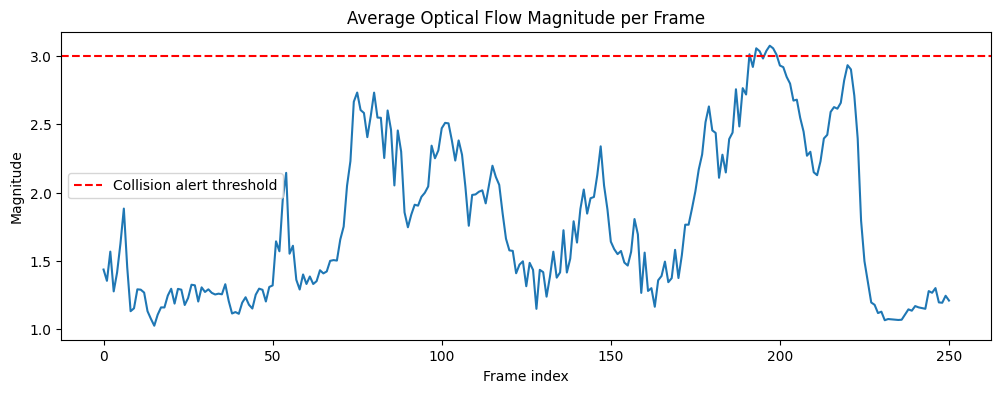

In [5]:
plt.figure(figsize=(12,4))
plt.plot(mag_history)
plt.axhline(COLLISION_THRESHOLD, color='red', linestyle='--', label="Collision alert threshold")
plt.title("Average Optical Flow Magnitude per Frame")
plt.xlabel("Frame index")
plt.ylabel("Magnitude")
plt.legend()
plt.show()

## 6. Display Frames Where Alerts Were Triggered

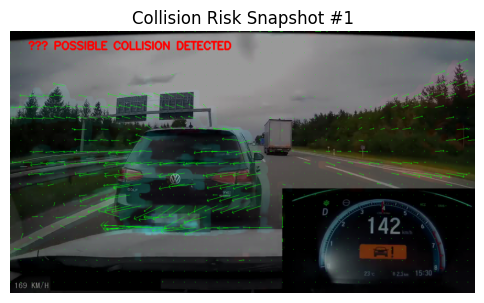

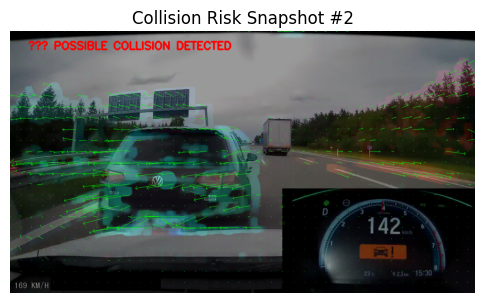

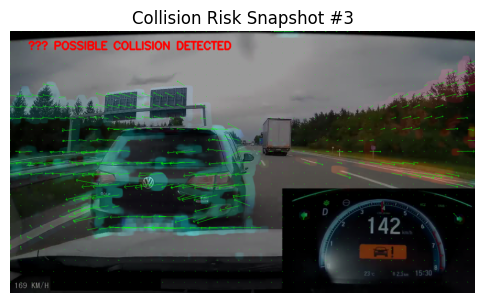

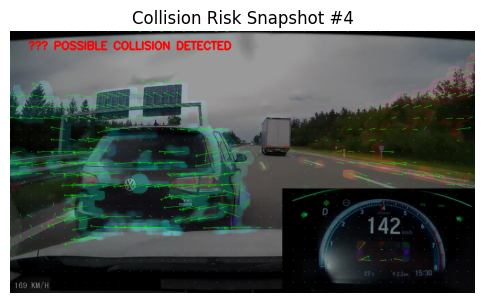

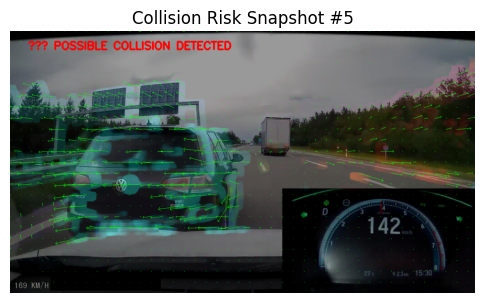

In [6]:
for i, f in enumerate(collision_alert_frames[:5]):  # Show first 5 alerts
    plt.figure(figsize=(6,4))
    plt.imshow(cv2.cvtColor(f, cv2.COLOR_BGR2RGB))
    plt.title(f"Collision Risk Snapshot #{i+1}")
    plt.axis('off')

## 7. Export Annotated Video Output

In [7]:
output_video = "output/optical_flow_analysis.mp4"

clip = ImageSequenceClip([cv2.cvtColor(f, cv2.COLOR_BGR2RGB) for f in frames_result], fps=fps)
clip.write_videofile(output_video, codec="libx264")

Video(output_video, embed=True)


MoviePy - Building video output/optical_flow_analysis.mp4.
MoviePy - Writing video output/optical_flow_analysis.mp4



MoviePy - Done !
MoviePy - video ready output/optical_flow_analysis.mp4
